# hddm

## importing things

In [1]:
import pandas
import matplotlib.pyplot as plt
import hddm
import numpy as np
from pandas import Series
import sys
import os
import seaborn as sns

from kabuki.analyze import check_geweke
from patsy import dmatrix

C:\Users\engel\anaconda3\envs\pyHDDM\lib\site-packages\IPython\parallel.py:13: ShimWarning: The `IPython.parallel` package has been deprecated since IPython 4.0. You should import from ipyparallel instead.
  "You should import from ipyparallel instead.", ShimWarning)


## check hddm version (should be 0.8)

In [2]:
print(hddm.__version__)


0.8.0


## import data

In [16]:
data = hddm.load_csv('clean.csv',delimiter = ',')
data['rt'] = data['rt']/1000
data = data[data['rt'] > 0.2]
data = hddm.utils.flip_errors(data) #flipping error  rts to be negative
data

,Unnamed: 0,subj_code,case,stimulus,text,purpose,trial_index,response,rt,condition,congruent
0,1,YPITJ6578R,noise,A university posted the following rule in a st...,1,1,6,1,3.354,full violation,1
1,2,YPITJ6578R,noise,A university posted the following rule in a st...,0,0,8,0,-1.567,no violation,1
2,3,YPITJ6578R,noise,A university posted the following rule in a st...,0,0,10,0,-2.433,no violation,1
3,4,YPITJ6578R,noise,A university posted the following rule in a st...,1,1,12,1,2.782,full violation,1
4,5,YPITJ6578R,noise,A university posted the following rule in a st...,1,1,14,1,2.216,full violation,1
...,...,...,...,...,...,...,...,...,...,...,...
12686,12687,JMBXF0003W,restaurant,A restaurant's customers had their meals inte...,0,1,229,1,1.131,purpose violation,0
12687,12688,JMBXF0003W,restaurant,A restaurant's customers had their meals inte...,1,0,231,0,-3.414,text violation,0
12688,12689,JMBXF0003W,restaurant,A restaurant's customers had their meals inte...,0,0,233,0,-1.774,no violation,1
12689,12690,JMBXF0003W,restaurant,A restaurant's customers had their meals inte...,1,0,235,0,-2.567,text violation,0


In [22]:
min(data['rt'])

-7.983

In [23]:
max(data['rt'])

7.982

## working directory

In [15]:
os.getcwd()

cd='C:\\Users\\engel\\Dropbox\\modelling textualism\\03 - full sample - violate dv - april 2023\\data'
os.chdir(cd)


#os.mkdir(cd + '/' + model_name)
#os.chdir(cd + '/' + model_name)

'C:\\Users\\engel\\Dropbox\\modelling textualism\\03 - full sample - violate dv - april 2023\\data'

### letting all parameters vary per condition

 [-----------------100%-----------------] 5001 of 5000 complete in 1373.9 secPlotting t(full violation)
Plotting t(no violation)
Plotting t(purpose violation)
Plotting t(text violation)
Plotting v(full violation)
Plotting v(no violation)
Plotting v(purpose violation)
Plotting v(text violation)
Plotting a(full violation)
Plotting a(no violation)
Plotting a(purpose violation)
Plotting a(text violation)
Plotting z(full violation)
Plotting z(no violation)
Plotting z(purpose violation)
Plotting z(text violation)


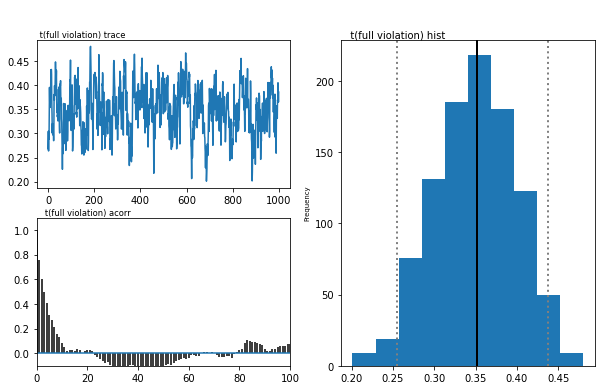

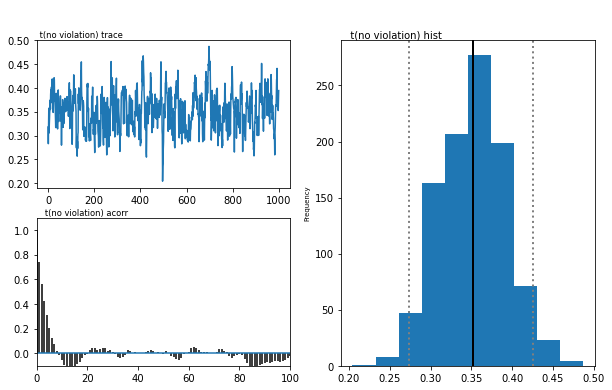

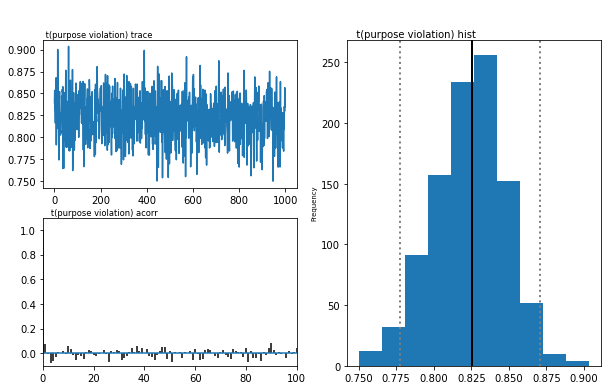

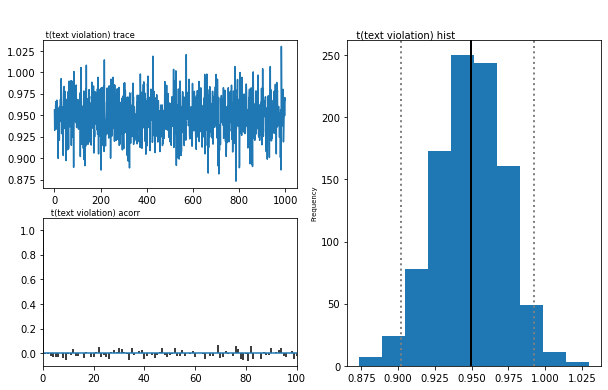

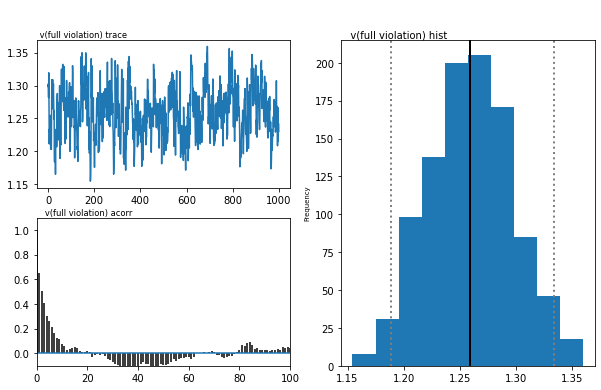

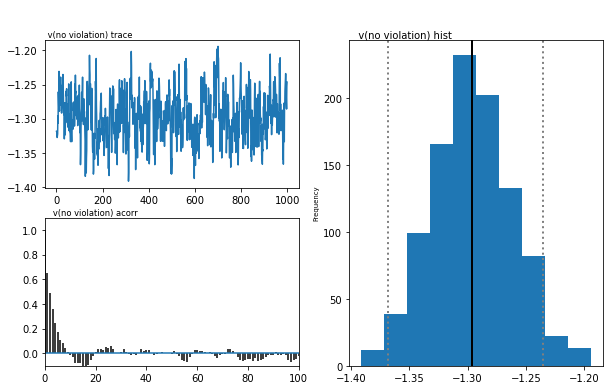

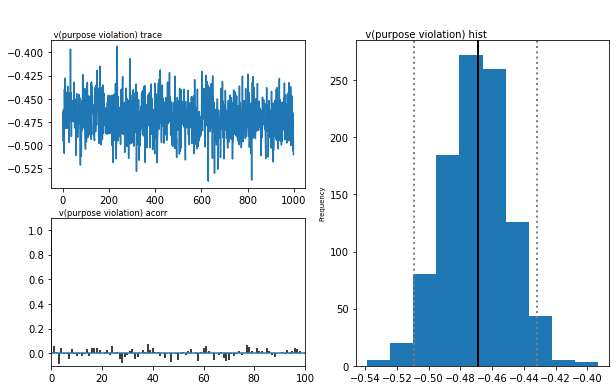

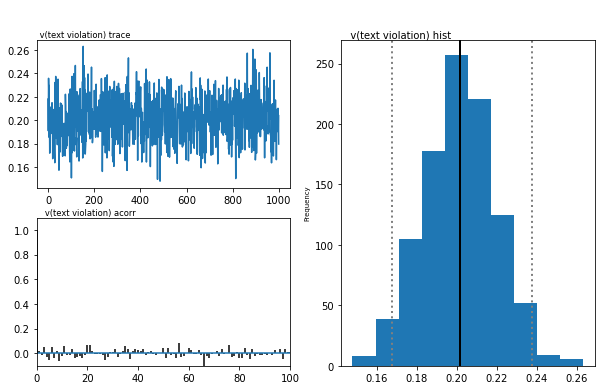

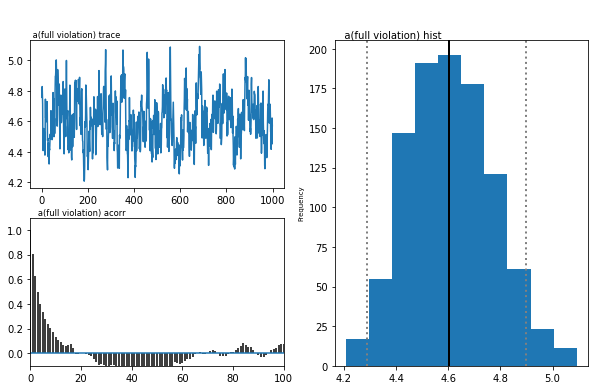

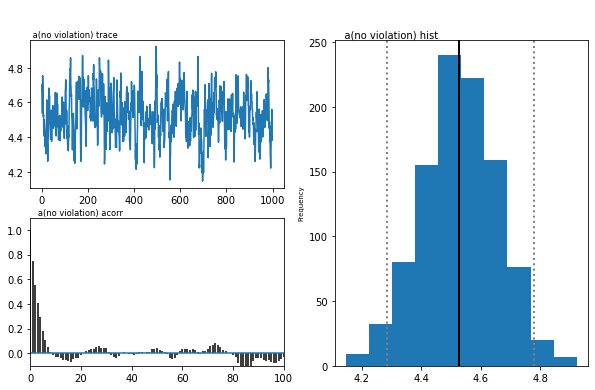

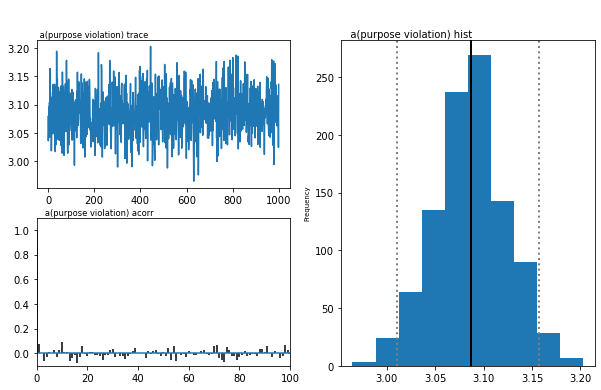

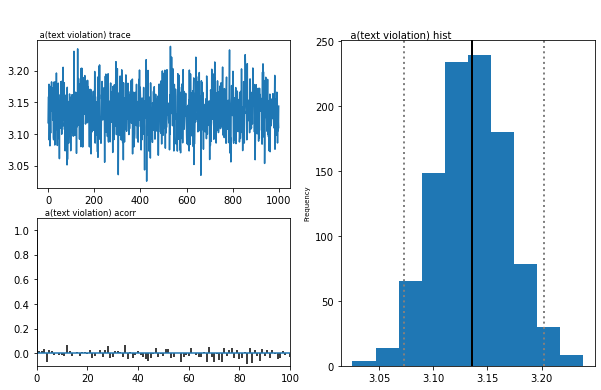

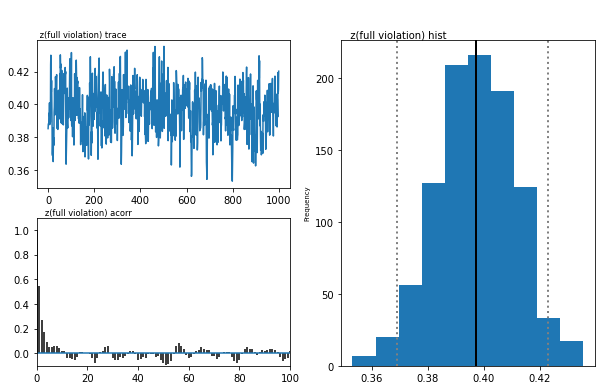

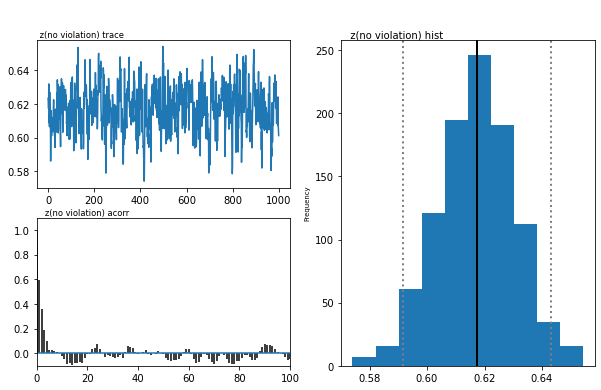

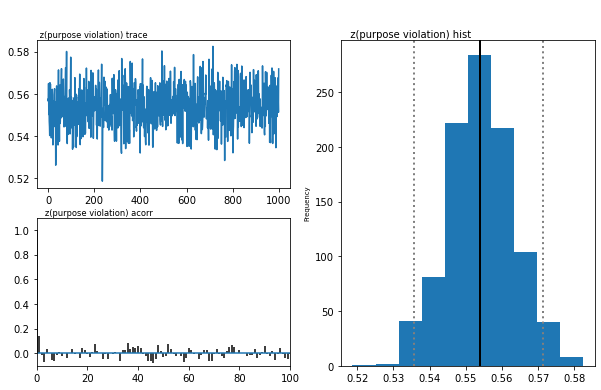

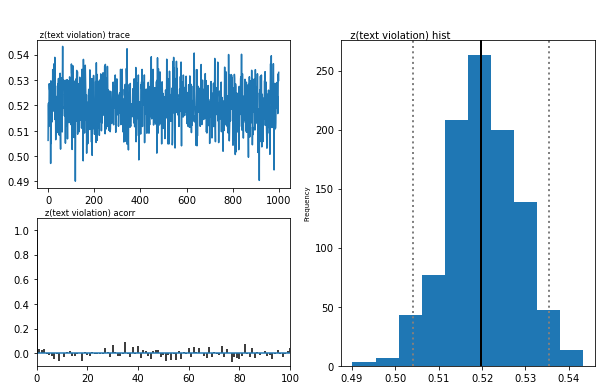

In [25]:
#setup
model_name = 'model full'

os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

samples = 5000
test_model = hddm.HDDM(data, include=('v', 'a', 'z', 't'), p_outlier=.05,depends_on={'v':'condition','a': 'condition','z': 'condition','t': 'condition'}) #including drift rate ('v'), boundary separation ('a'), starting point ('z'), and non-decision time ('t'), 5% of the data points are considered potential outliers

#starting values
#test_model.find_starting_values()

#sampling, and saving the samples from the posterior distributions to the specified database
test_model.sample(samples, burn=samples/5, thin=4, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')

#save model
test_model.save(model_name)

#print the model statistics and save them to a text file
test_model.print_stats(model_name + '_dic.txt')

#generating and saving summary statistics for the drift diffusion model
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

#create and save posterior distribution plots for the parameters of the drift diffusion model
test_model.plot_posteriors(['t'], save=True) #non-decision time
test_model.plot_posteriors(['v'], save=True) #drift rate
test_model.plot_posteriors(['a'], save=True) #boundary separation
test_model.plot_posteriors(['z'], save=True) #starting point

#load model, get parameter traces that were generated during the sampling process, and save them
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')



### parameters and DIC

In [34]:
test_model.print_stats()

                          mean         std      2.5q       25q       50q       75q     97.5q       mc err
a(full violation)       4.6083    0.160866   4.31257   4.49142   4.60439   4.71811   4.93838    0.0119338
a(no violation)        4.53051    0.126967   4.27195   4.44864   4.52854    4.6172   4.77269   0.00861822
a(purpose violation)    3.0868   0.0375705   3.01183   3.06269   3.08696   3.11063   3.16233   0.00117226
a(text violation)      3.13544    0.033363   3.07199   3.11284   3.13607    3.1575   3.20158   0.00109636
v(full violation)      1.25946   0.0372531   1.18928   1.23354   1.25936   1.28461   1.33573   0.00250323
v(no violation)       -1.29606   0.0346175  -1.36301  -1.31955   -1.2965  -1.27294   -1.2277   0.00222206
v(purpose violation) -0.469611    0.020202 -0.509424  -0.48248  -0.46912 -0.456659  -0.43178  0.000633269
v(text violation)     0.201443   0.0181384  0.166325  0.189383  0.201759   0.21295  0.236449  0.000564723
t(full violation)     0.349284   0.0489421   0

### plot parameters

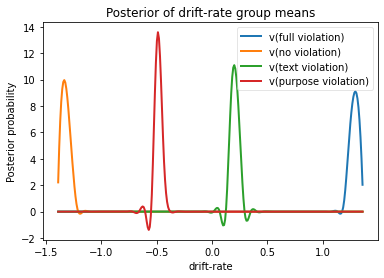

In [29]:
v_full, v_no, v_text, v_purpose = test_model.nodes_db.node[['v(full violation)', 'v(no violation)', 'v(text violation)','v(purpose violation)']]
hddm.analyze.plot_posterior_nodes([v_full, v_no, v_text, v_purpose])
plt.xlabel('drift-rate')
plt.ylabel('Posterior probability')
plt.title('Posterior of drift-rate group means')
plt.savefig('v_per_condition.pdf')

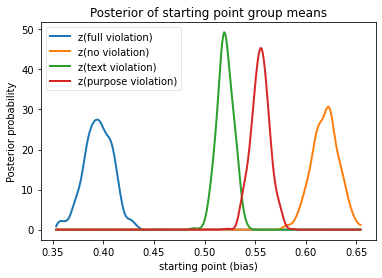

In [30]:
z_full, z_no, z_text, z_purpose = test_model.nodes_db.node[['z(full violation)', 'z(no violation)', 'z(text violation)','z(purpose violation)']]
hddm.analyze.plot_posterior_nodes([z_full, z_no, z_text, z_purpose])
plt.xlabel('starting point (bias)')
plt.ylabel('Posterior probability')
plt.title('Posterior of starting point group means')
plt.savefig('z_per_condition.pdf')

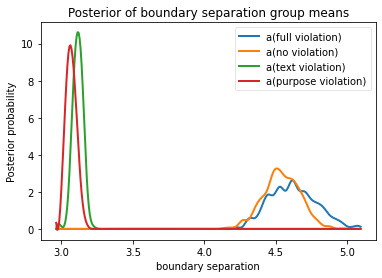

In [31]:
a_full, a_no, a_text, a_purpose = test_model.nodes_db.node[['a(full violation)', 'a(no violation)', 'a(text violation)','a(purpose violation)']]
hddm.analyze.plot_posterior_nodes([a_full, a_no, a_text, a_purpose])
plt.xlabel('boundary separation')
plt.ylabel('Posterior probability')
plt.title('Posterior of boundary separation group means')
plt.savefig('a_per_condition.pdf')

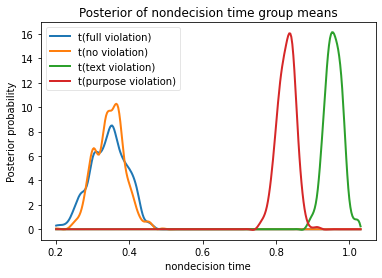

In [32]:
t_full, t_no, t_text, t_purpose = test_model.nodes_db.node[['t(full violation)', 't(no violation)', 't(text violation)','t(purpose violation)']]
hddm.analyze.plot_posterior_nodes([t_full, t_no, t_text, t_purpose])
plt.xlabel('nondecision time')
plt.ylabel('Posterior probability')
plt.title('Posterior of nondecision time group means')
plt.savefig('t_per_condition.pdf')

## model with just v, t, and a (no z)

 [-----------------100%-----------------] 5000 of 5000 complete in 1768.5 secPlotting t(full violation)
Plotting t(no violation)
Plotting t(purpose violation)
Plotting t(text violation)
Plotting v(full violation)
Plotting v(no violation)
Plotting v(purpose violation)
Plotting v(text violation)
Plotting a(full violation)
Plotting a(no violation)
Plotting a(purpose violation)
Plotting a(text violation)
Plotting z


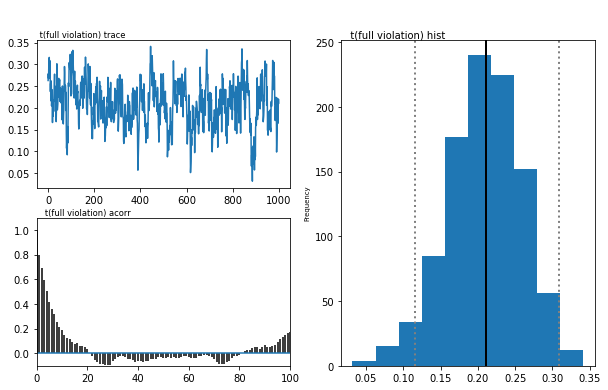

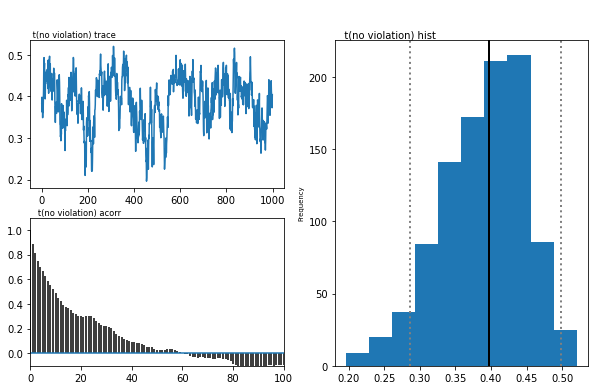

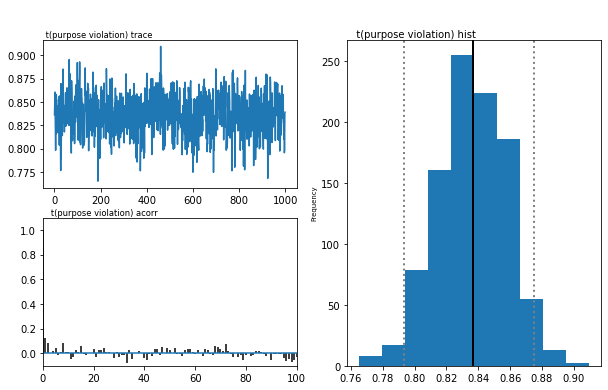

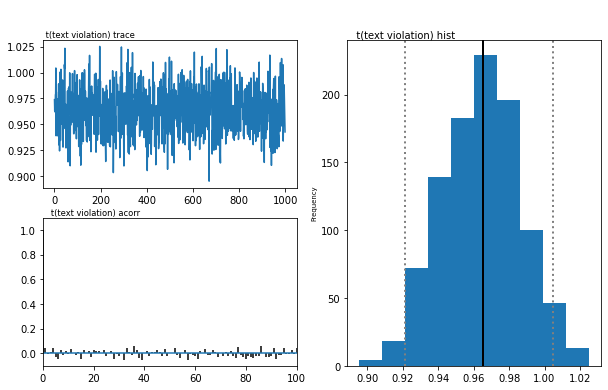

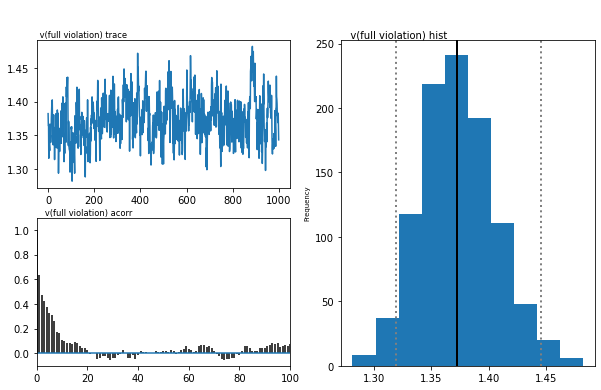

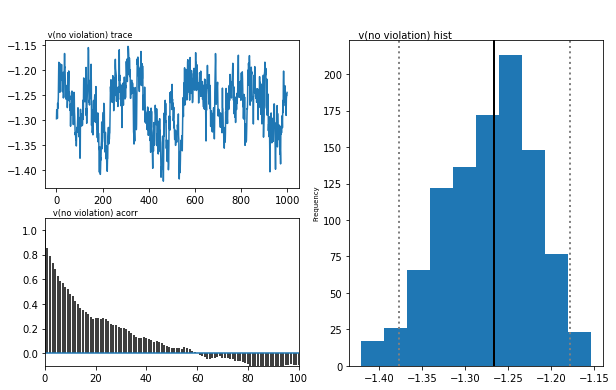

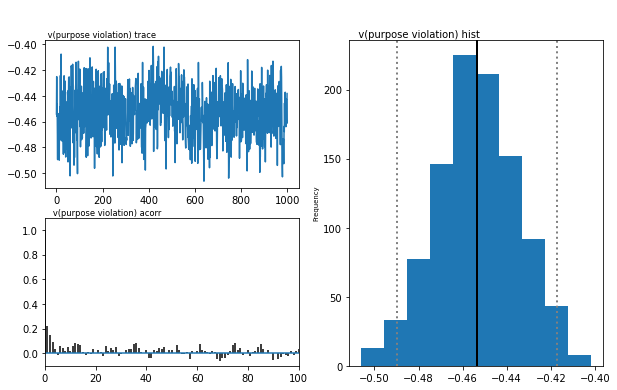

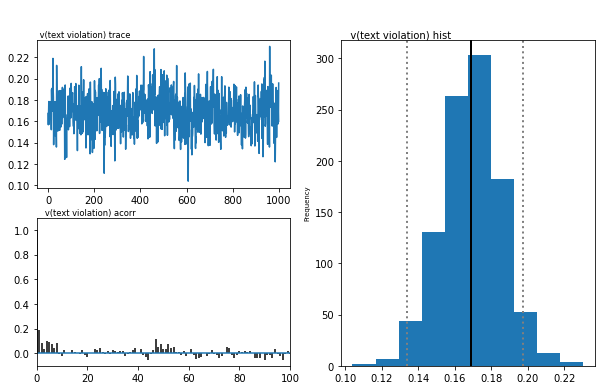

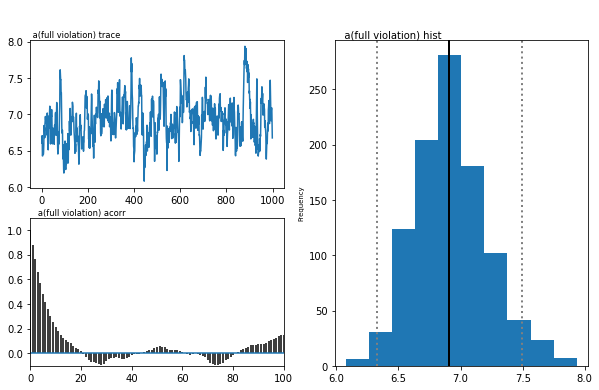

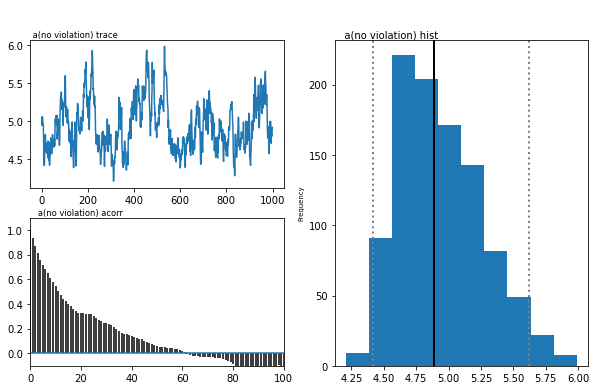

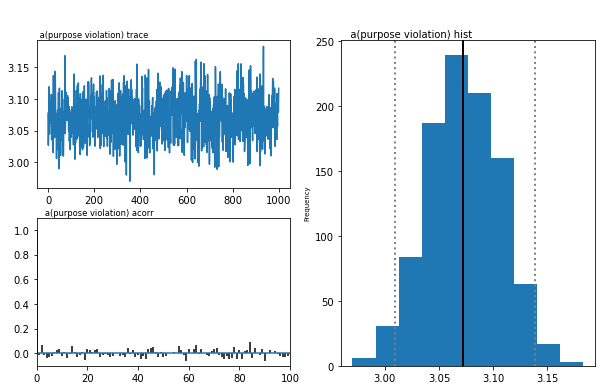

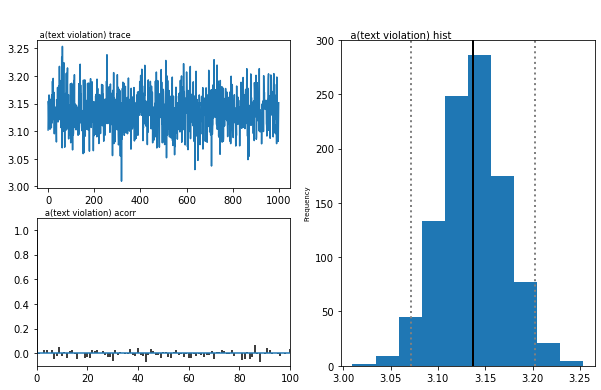

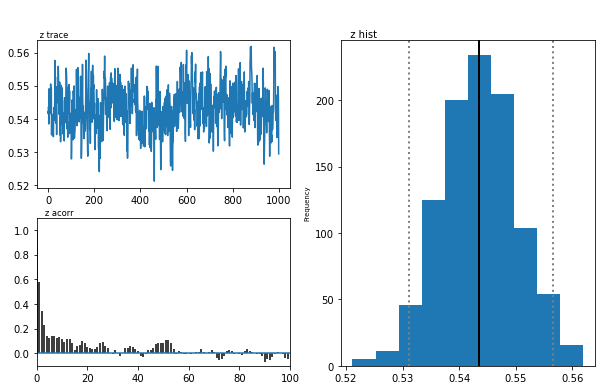

In [35]:
#setup
model_name = 'model VTA'

os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

samples = 5000
test_model = hddm.HDDM(data, include=('v', 'a', 'z', 't'), p_outlier=.05,depends_on={'v':'condition','a': 'condition','t': 'condition'}) #including drift rate ('v'), boundary separation ('a'), and non-decision time ('t'), 5% of the data points are considered potential outliers

#starting values
#test_model.find_starting_values()

#sampling, and saving the samples from the posterior distributions to the specified database
test_model.sample(samples, burn=samples/5, thin=4, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')

#save model
test_model.save(model_name)

#print the model statistics and save them to a text file
test_model.print_stats(model_name + '_dic.txt')

#generating and saving summary statistics for the drift diffusion model
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

#create and save posterior distribution plots for the parameters of the drift diffusion model
test_model.plot_posteriors(['t'], save=True) #non-decision time
test_model.plot_posteriors(['v'], save=True) #drift rate
test_model.plot_posteriors(['a'], save=True) #boundary separation
test_model.plot_posteriors(['z'], save=True) #starting point

#load model, get parameter traces that were generated during the sampling process, and save them
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')

In [ ]:
### parameters and DIC

In [36]:
test_model.print_stats()

                          mean         std       2.5q       25q       50q       75q     97.5q       mc err
a(full violation)      6.92674    0.293765    6.42393   6.72248   6.90922   7.10314   7.61123     0.023631
a(no violation)        4.94189    0.324813     4.4312   4.69566   4.88844   5.16995   5.66795    0.0294147
a(purpose violation)   3.07284   0.0337281    3.00653    3.0493   3.07248   3.09703    3.1373   0.00102522
a(text violation)      3.13695   0.0338073    3.07315   3.11455   3.13679   3.15936   3.20474   0.00104112
v(full violation)      1.37309   0.0324152    1.31362   1.35088   1.37233   1.39449   1.44281   0.00224323
v(no violation)       -1.27247   0.0526379   -1.38506  -1.31054    -1.266  -1.23419  -1.18111   0.00455507
v(purpose violation) -0.453276   0.0184877   -0.49075 -0.465203 -0.453488 -0.440703 -0.417528  0.000789147
v(text violation)     0.168732   0.0165291    0.13607  0.158338  0.168801  0.179665  0.201775  0.000715142
t(full violation)     0.209307   0.04

## model with just v,a, and z (no t)

 [-----------------100%-----------------] 5001 of 5000 complete in 1321.0 secPlotting t
Plotting v(full violation)
Plotting v(no violation)
Plotting v(purpose violation)
Plotting v(text violation)
Plotting a(full violation)
Plotting a(no violation)
Plotting a(purpose violation)
Plotting a(text violation)
Plotting z(full violation)
Plotting z(no violation)
Plotting z(purpose violation)
Plotting z(text violation)


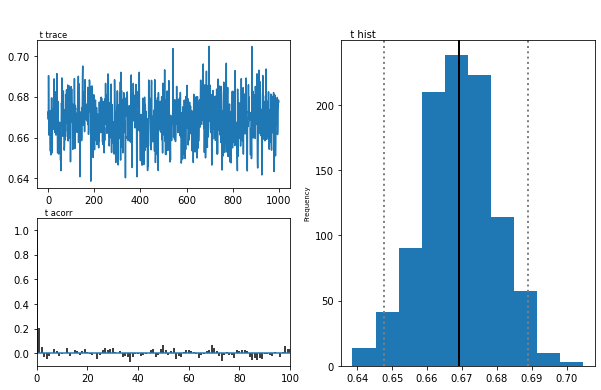

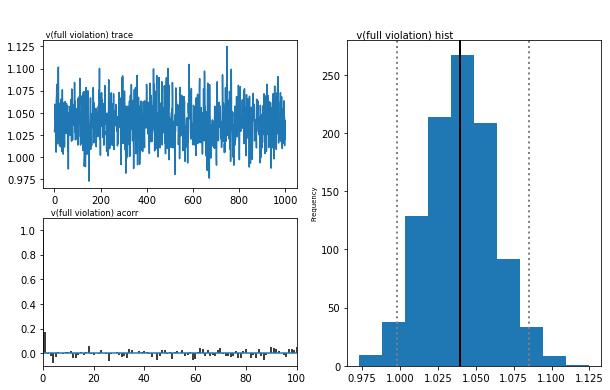

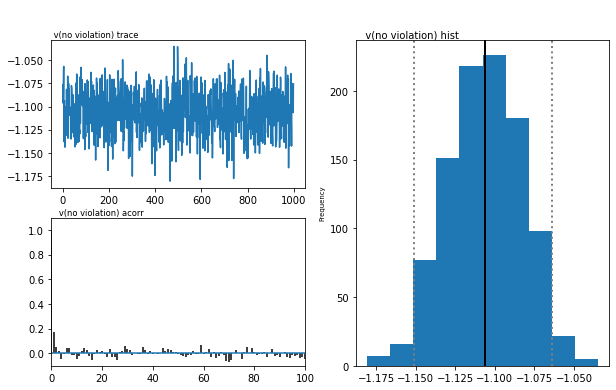

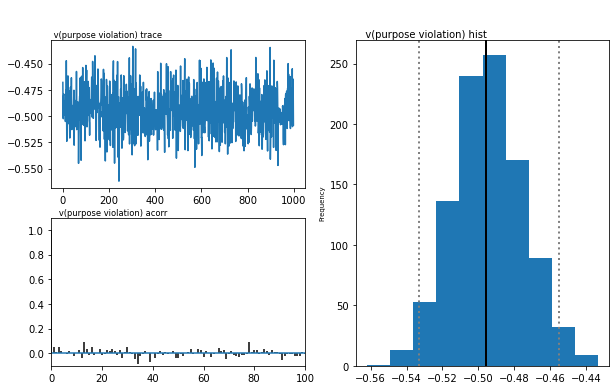

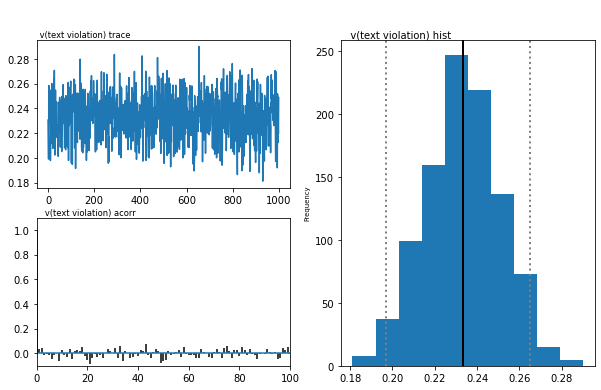

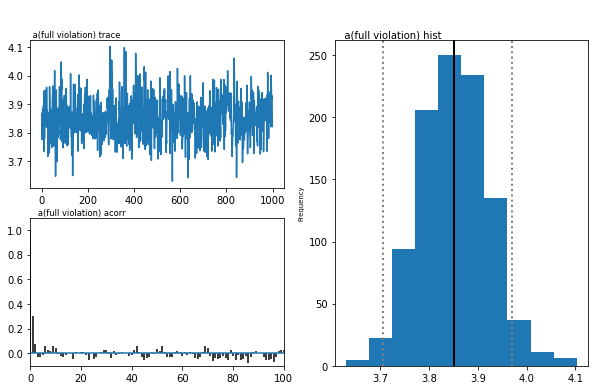

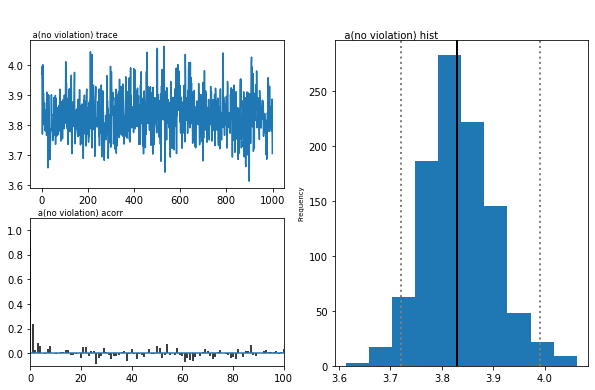

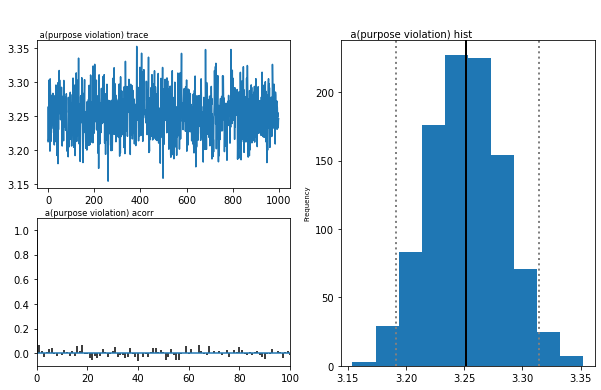

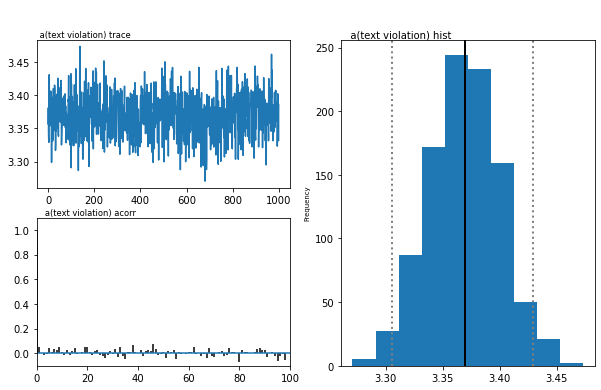

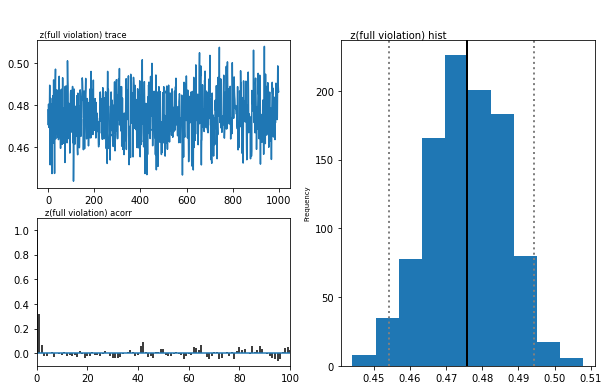

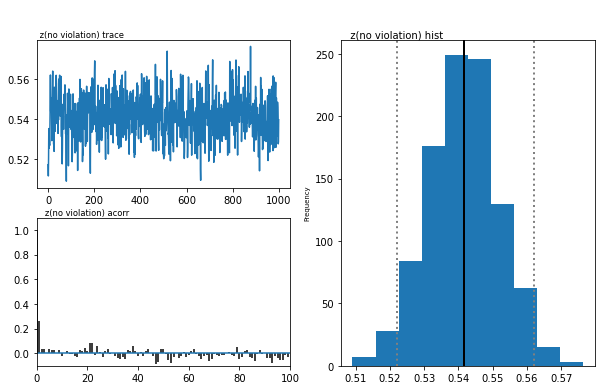

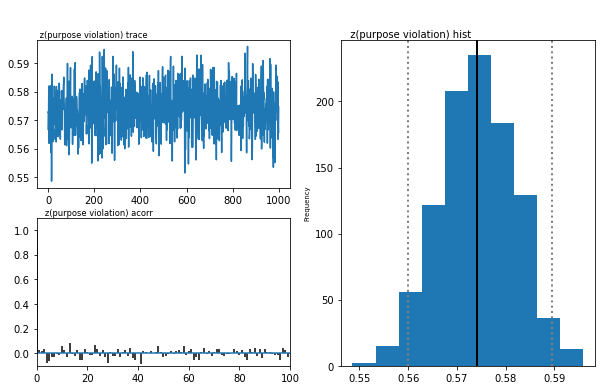

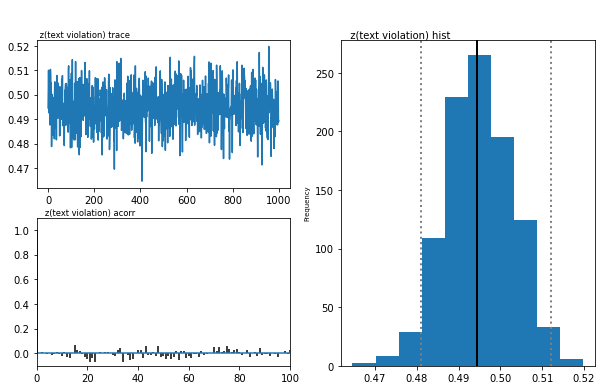

In [37]:
#setup
model_name = 'model VAZ'

os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

samples = 5000
test_model = hddm.HDDM(data, include=('v', 'a', 'z', 't'), p_outlier=.05,depends_on={'v':'condition','a': 'condition','z': 'condition'}) #including drift rate ('v'), boundary separation ('a'), and non-decision time ('t'), 5% of the data points are considered potential outliers

#starting values
#test_model.find_starting_values()

#sampling, and saving the samples from the posterior distributions to the specified database
test_model.sample(samples, burn=samples/5, thin=4, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')

#save model
test_model.save(model_name)

#print the model statistics and save them to a text file
test_model.print_stats(model_name + '_dic.txt')

#generating and saving summary statistics for the drift diffusion model
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

#create and save posterior distribution plots for the parameters of the drift diffusion model
test_model.plot_posteriors(['t'], save=True) #non-decision time
test_model.plot_posteriors(['v'], save=True) #drift rate
test_model.plot_posteriors(['a'], save=True) #boundary separation
test_model.plot_posteriors(['z'], save=True) #starting point

#load model, get parameter traces that were generated during the sampling process, and save them
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')

In [ ]:
### parameters and DIC

In [38]:
test_model.print_stats()

                          mean         std      2.5q       25q       50q       75q     97.5q       mc err
a(full violation)      3.85229   0.0700686   3.72376   3.80447   3.85109   3.89793   3.99918   0.00280387
a(no violation)        3.83444   0.0666124   3.70674   3.78987   3.82949   3.87834    3.9813   0.00280944
a(purpose violation)   3.25168   0.0318047    3.1916   3.22891   3.25143   3.27378   3.31622   0.00115964
a(text violation)      3.36891   0.0310685   3.30767    3.3475   3.36933   3.39026    3.4321   0.00104049
v(full violation)      1.03984   0.0224079  0.997032   1.02537   1.03925   1.05544   1.08429   0.00076986
v(no violation)       -1.10618   0.0233729  -1.15121  -1.12255  -1.10609  -1.08898  -1.06308  0.000852116
v(purpose violation)  -0.49437   0.0197682 -0.531491 -0.507621 -0.495568 -0.481196 -0.453508  0.000716614
v(text violation)      0.23323   0.0177295  0.197846  0.221601  0.233501  0.245288  0.266736  0.000568491
t                     0.668971   0.0104314  0.

DIC is larger than with previous models, but graphs looks better (trace and autocorrelation)...

## model with just v,t, and z (no a)

 [-----------------100%-----------------] 5000 of 5000 complete in 1676.3 secPlotting t(full violation)
Plotting t(no violation)
Plotting t(purpose violation)
Plotting t(text violation)
Plotting v(full violation)
Plotting v(no violation)
Plotting v(purpose violation)
Plotting v(text violation)
Plotting a
Plotting z(full violation)
Plotting z(no violation)
Plotting z(purpose violation)
Plotting z(text violation)


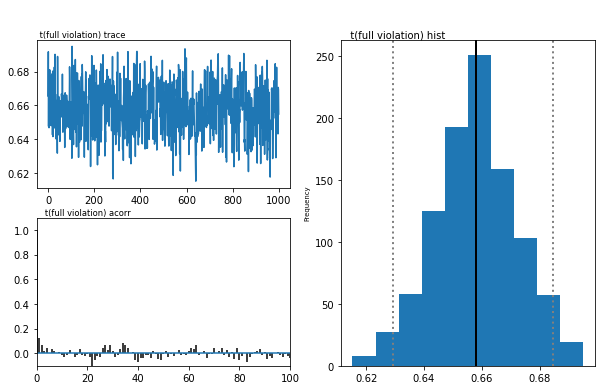

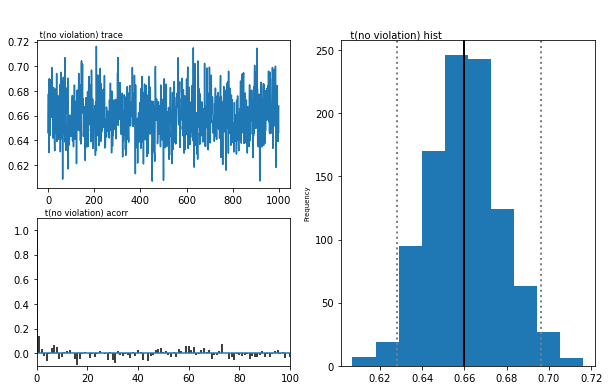

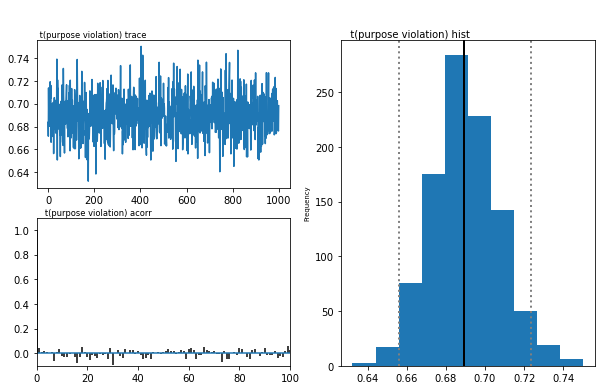

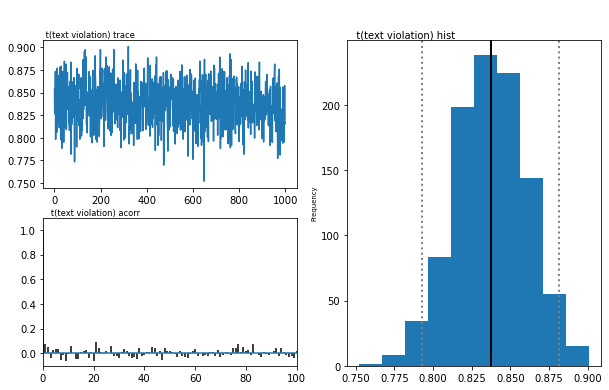

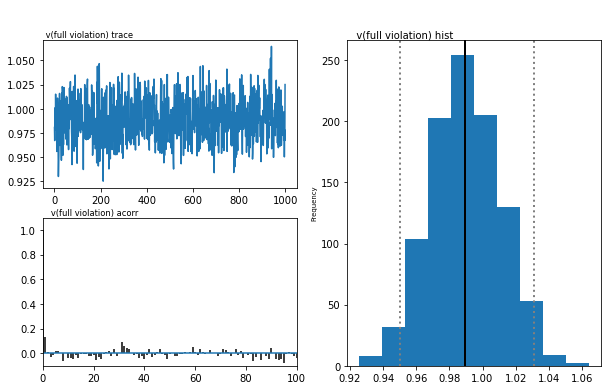

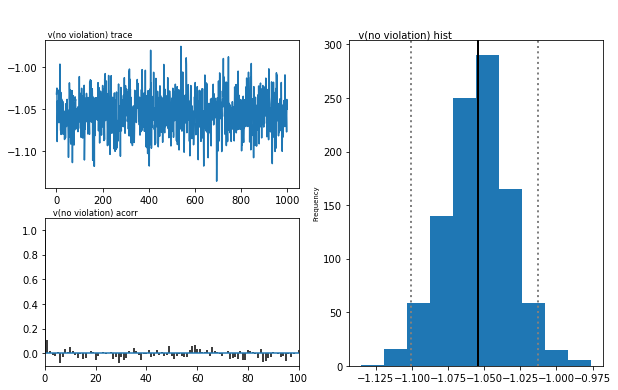

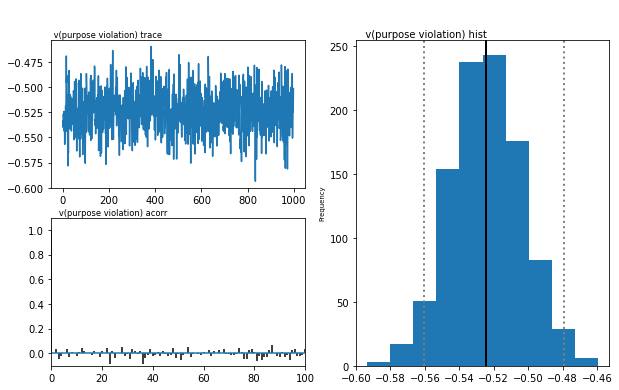

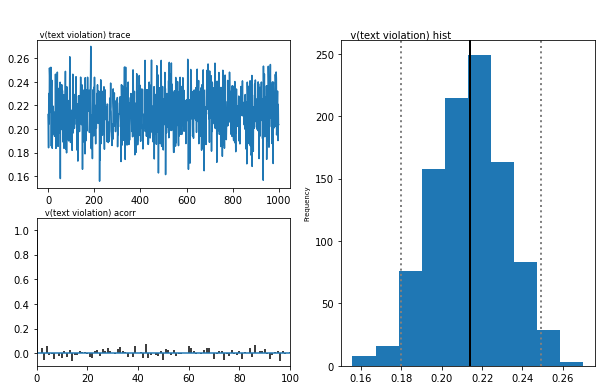

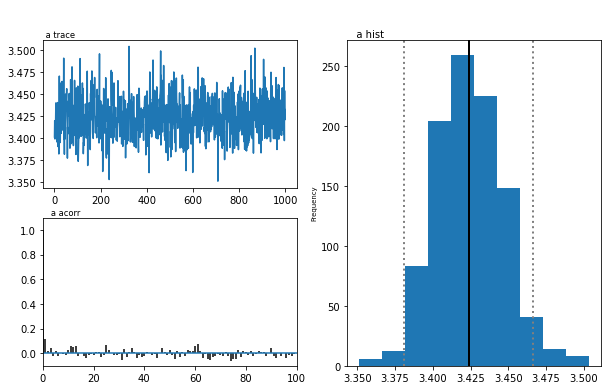

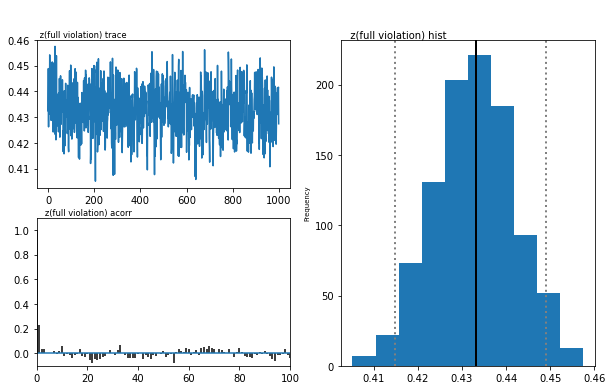

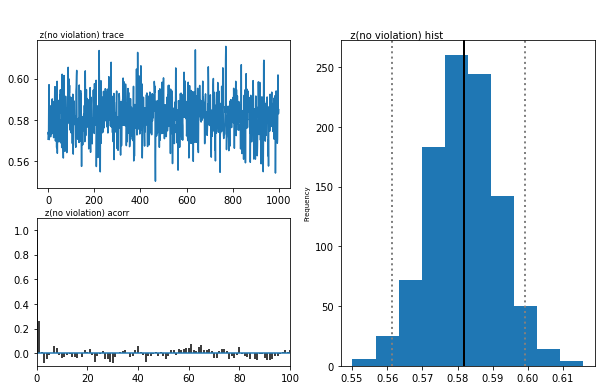

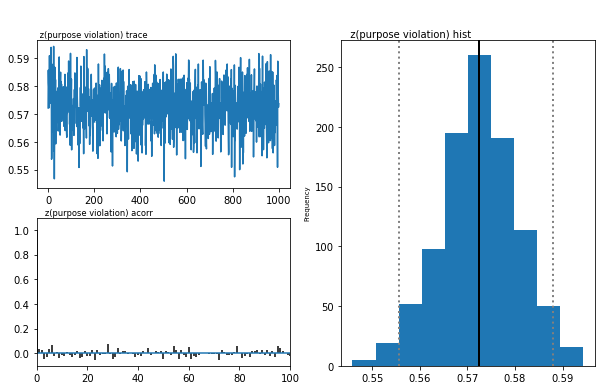

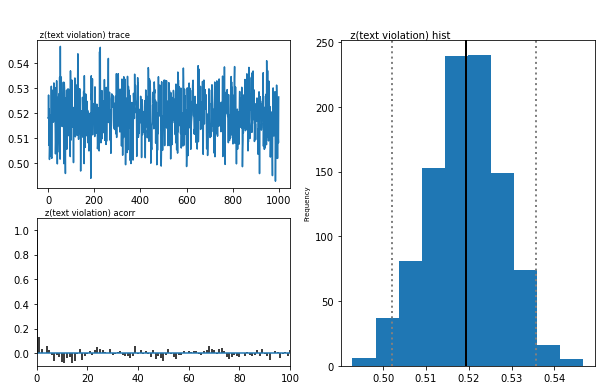

In [40]:
#setup
model_name = 'model VTZ'

os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

samples = 5000
test_model = hddm.HDDM(data, include=('v', 'a', 'z', 't'), p_outlier=.05,depends_on={'v':'condition','t': 'condition','z': 'condition'}) #including drift rate ('v'), boundary separation ('a'), and non-decision time ('t'), 5% of the data points are considered potential outliers

#starting values
#test_model.find_starting_values()

#sampling, and saving the samples from the posterior distributions to the specified database
test_model.sample(samples, burn=samples/5, thin=4, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')

#save model
test_model.save(model_name)

#print the model statistics and save them to a text file
test_model.print_stats(model_name + '_dic.txt')

#generating and saving summary statistics for the drift diffusion model
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

#create and save posterior distribution plots for the parameters of the drift diffusion model
test_model.plot_posteriors(['t'], save=True) #non-decision time
test_model.plot_posteriors(['v'], save=True) #drift rate
test_model.plot_posteriors(['a'], save=True) #boundary separation
test_model.plot_posteriors(['z'], save=True) #starting point

#load model, get parameter traces that were generated during the sampling process, and save them
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')

### parameters and DIC

In [41]:
test_model.print_stats()

                          mean         std      2.5q       25q       50q       75q     97.5q       mc err
a                      3.42429   0.0225639   3.38377   3.40803   3.42401   3.43884   3.47088  0.000749171
v(full violation)     0.989734   0.0213448  0.950083   0.97559  0.989386   1.00449   1.03113  0.000732807
v(no violation)       -1.05469    0.022209  -1.09843  -1.06926  -1.05407  -1.03979  -1.01021  0.000712913
v(purpose violation) -0.524185   0.0204438 -0.565681 -0.538416 -0.524686 -0.510597 -0.483194  0.000658111
v(text violation)     0.213648   0.0182273  0.179759  0.201114  0.213798  0.225839  0.249199  0.000583458
t(full violation)      0.65795   0.0141186  0.629505  0.648444  0.657966  0.667398  0.685158   0.00053776
t(no violation)        0.66006   0.0173535  0.628072  0.648557   0.65991   0.67099  0.696959  0.000609908
t(purpose violation)  0.689708   0.0172978  0.657118  0.678365   0.68901   0.70069  0.726965  0.000604635
t(text violation)      0.83768   0.0229893  0.

## model with just a,t, and z (no v)

 [-----------------100%-----------------] 5001 of 5000 complete in 1325.6 secPlotting t(full violation)
Plotting t(no violation)
Plotting t(purpose violation)
Plotting t(text violation)
Plotting v
Plotting a(full violation)
Plotting a(no violation)
Plotting a(purpose violation)
Plotting a(text violation)
Plotting z(full violation)
Plotting z(no violation)
Plotting z(purpose violation)
Plotting z(text violation)


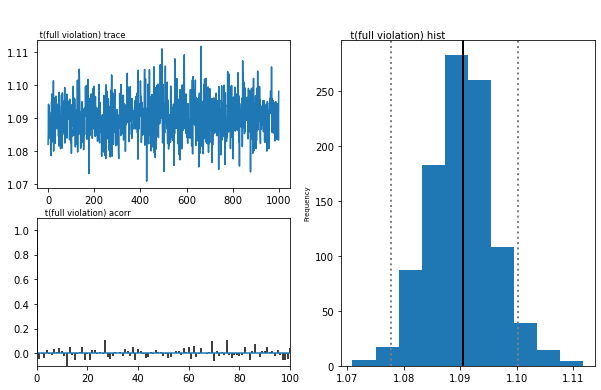

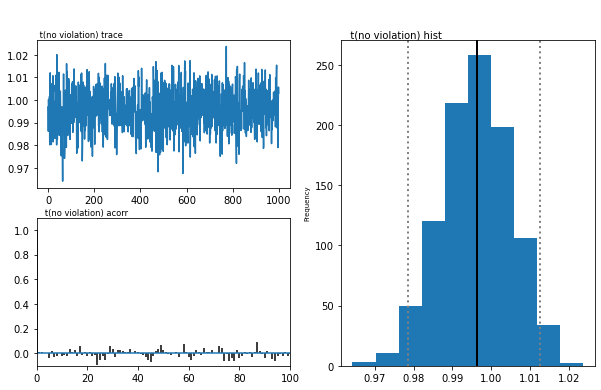

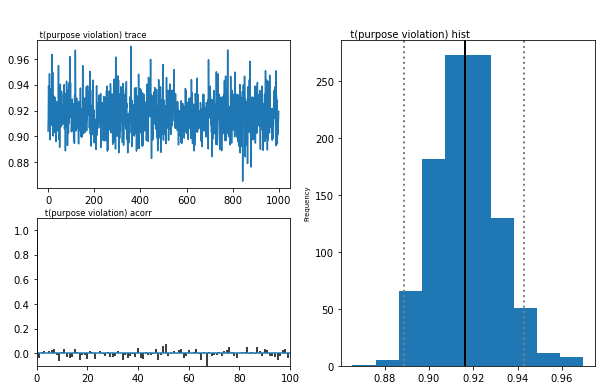

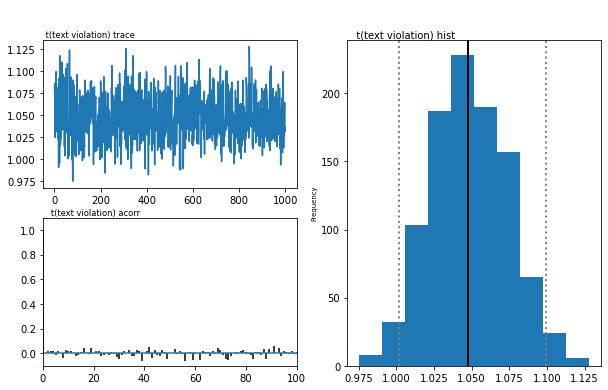

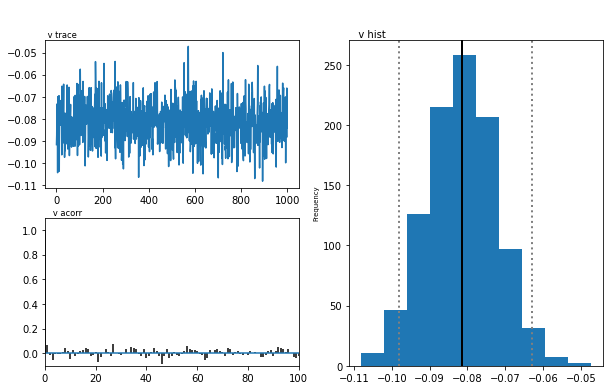

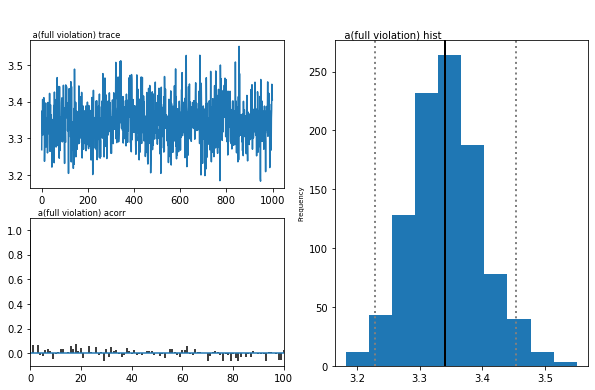

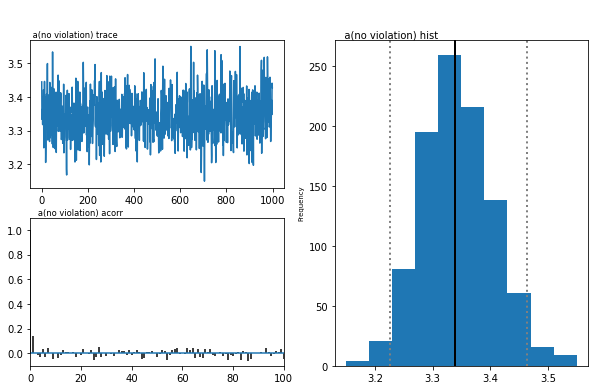

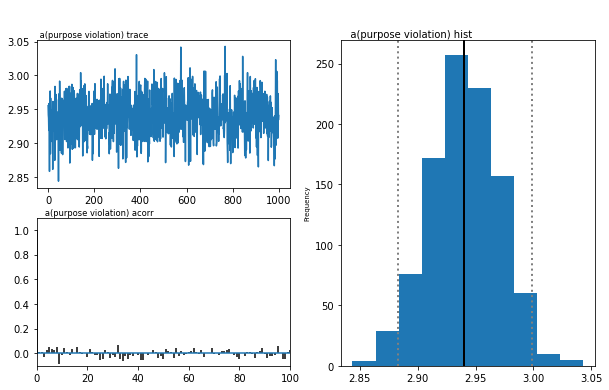

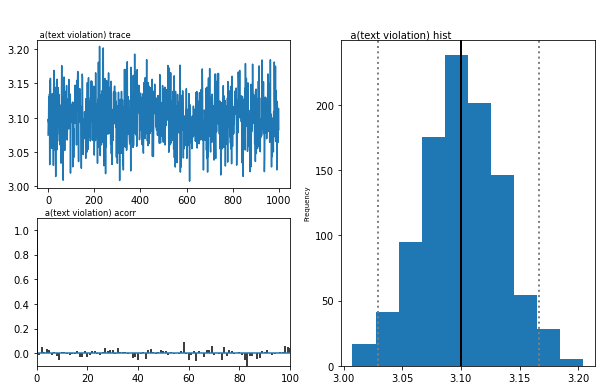

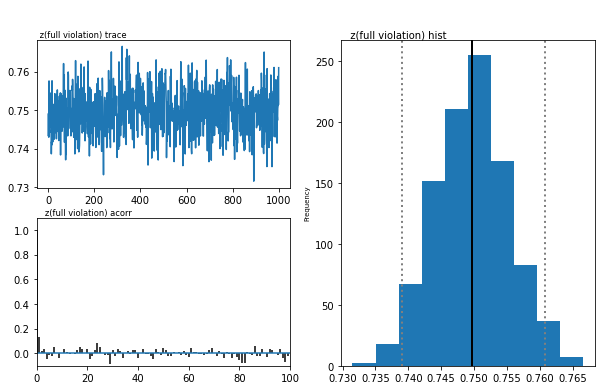

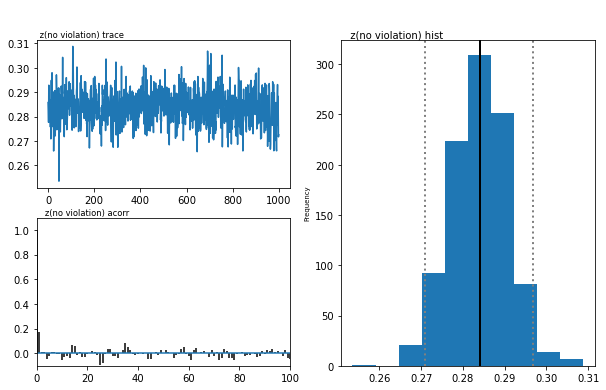

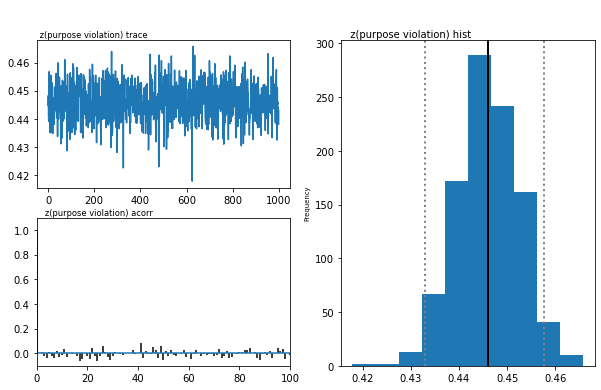

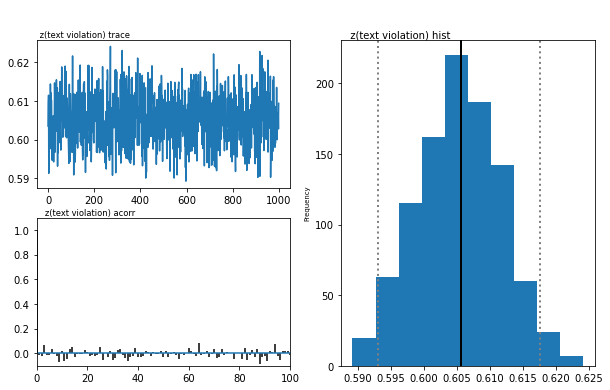

In [42]:
#setup
model_name = 'model ATZ'

os.mkdir(cd + '/' + model_name)
os.chdir(cd + '/' + model_name)

samples = 5000
test_model = hddm.HDDM(data, include=('v', 'a', 'z', 't'), p_outlier=.05,depends_on={'a':'condition','t': 'condition','z': 'condition'}) #including drift rate ('v'), boundary separation ('a'), and non-decision time ('t'), 5% of the data points are considered potential outliers

#starting values
#test_model.find_starting_values()

#sampling, and saving the samples from the posterior distributions to the specified database
test_model.sample(samples, burn=samples/5, thin=4, dbname=os.path.join(cd, model_name, model_name + '_trace'), db='pickle')

#save model
test_model.save(model_name)

#print the model statistics and save them to a text file
test_model.print_stats(model_name + '_dic.txt')

#generating and saving summary statistics for the drift diffusion model
test_model_output = test_model.gen_stats()
test_model_output.to_csv(model_name + '_output.csv')

#create and save posterior distribution plots for the parameters of the drift diffusion model
test_model.plot_posteriors(['t'], save=True) #non-decision time
test_model.plot_posteriors(['v'], save=True) #drift rate
test_model.plot_posteriors(['a'], save=True) #boundary separation
test_model.plot_posteriors(['z'], save=True) #starting point

#load model, get parameter traces that were generated during the sampling process, and save them
test_model = hddm.load(model_name)
results = test_model.get_traces()
results.to_csv(model_name + '_within_traces.csv')

### parameters and DIC

In [43]:
test_model.print_stats()

                           mean         std       2.5q        25q        50q        75q      97.5q       mc err
a(full violation)       3.34325   0.0568409    3.23676    3.30438    3.34099    3.37976    3.46555   0.00191653
a(no violation)          3.3437   0.0619547    3.23141    3.30234    3.33931    3.38444    3.47128    0.0020212
a(purpose violation)    2.94051   0.0302338    2.88004    2.92063    2.93997    2.96145    2.99595  0.000929429
a(text violation)       3.10055   0.0337825    3.03077    3.07732    3.09994    3.12372    3.16905   0.00116537
v                    -0.0815137  0.00923113 -0.0995497 -0.0879154 -0.0815153 -0.0754942 -0.0636432  0.000301797
t(full violation)       1.09032  0.00574548    1.07933    1.08656    1.09043    1.09404    1.10198  0.000181483
t(no violation)        0.996051  0.00901414    0.97848   0.989716   0.996297    1.00251    1.01252   0.00028795
t(purpose violation)   0.916797   0.0142818   0.891204   0.906673   0.916384   0.925935   0.946556  0.00

# inspect final model (az)

In [55]:
#load model
model = hddm.load('C:\\Users\\engel\\Dropbox\\alternative possibilities\\03 - main study good vs bad vs neutral victim\\hddm\\modelAZ\\modelAZ')

,mean,std,2.5q,25q,50q,75q,97.5q,mc err
a(bad),2.44861,0.0866761,2.35198,2.41673,2.4513,2.48519,2.54632,0.00194016
a(good),2.4531,0.0858238,2.36061,2.42289,2.45497,2.48459,2.55894,0.00194448
a(neutral),2.36206,0.0828422,2.27289,2.33192,2.36377,2.39559,2.45774,0.00165278
a_std,0.345857,0.0313903,0.286813,0.326249,0.345841,0.366049,0.403906,0.00152914
a_subj(neutral).AAERS6157Q,1.88974,0.24227,1.47564,1.72428,1.87292,2.03287,2.39427,0.00772963
...,...,...,...,...,...,...,...,...
z_subj(neutral).ZTAQR1734W,0.521564,0.0269724,0.481501,0.507911,0.519605,0.534245,0.571757,0.0010435
z_subj(good).ZVZXL1507M,0.507895,0.0274003,0.46216,0.495234,0.507893,0.520275,0.561317,0.00122257
z_subj(bad).ZWICA9713R,0.466784,0.0258412,0.423236,0.453403,0.466081,0.481067,0.514686,0.00107377
z_subj(bad).ZXMNF2715H,0.466818,0.0267753,0.420104,0.453794,0.467111,0.47987,0.515679,0.0010136


In [64]:
results_final = model.gen_stats() # contains point estimates and HDIs

print(results_final)

                                mean        std      2.5q       25q       50q  \
a(bad)                       2.44861  0.0866761   2.35198   2.41673    2.4513   
a(good)                       2.4531  0.0858238   2.36061   2.42289   2.45497   
a(neutral)                   2.36206  0.0828422   2.27289   2.33192   2.36377   
a_std                       0.345857  0.0313903  0.286813  0.326249  0.345841   
a_subj(neutral).AAERS6157Q   1.88974    0.24227   1.47564   1.72428   1.87292   
...                              ...        ...       ...       ...       ...   
z_subj(neutral).ZTAQR1734W  0.521564  0.0269724  0.481501  0.507911  0.519605   
z_subj(good).ZVZXL1507M     0.507895  0.0274003   0.46216  0.495234  0.507893   
z_subj(bad).ZWICA9713R      0.466784  0.0258412  0.423236  0.453403  0.466081   
z_subj(bad).ZXMNF2715H      0.466818  0.0267753  0.420104  0.453794  0.467111   
z_subj(neutral).ZYTZF4550B  0.518263  0.0266212  0.475391  0.505124  0.517381   

                           

In [66]:
#point estimates and HDIs for a

print(results_final.loc["a(bad)"])
print(results_final.loc["a(good)"])
print(results_final.loc["a(neutral)"])

mean         2.44861
std        0.0866761
2.5q         2.35198
25q          2.41673
50q           2.4513
75q          2.48519
97.5q        2.54632
mc err    0.00194016
Name: a(bad), dtype: object
mean          2.4531
std        0.0858238
2.5q         2.36061
25q          2.42289
50q          2.45497
75q          2.48459
97.5q        2.55894
mc err    0.00194448
Name: a(good), dtype: object
mean         2.36206
std        0.0828422
2.5q         2.27289
25q          2.33192
50q          2.36377
75q          2.39559
97.5q        2.45774
mc err    0.00165278
Name: a(neutral), dtype: object


In [67]:
#point estimates and HDIs for z

print(results_final.loc["z(bad)"])
print(results_final.loc["z(good)"])
print(results_final.loc["z(neutral)"])

mean         0.469472
std         0.0172504
2.5q         0.448323
25q          0.462754
50q          0.470245
75q          0.477487
97.5q        0.489961
mc err    0.000915515
Name: z(bad), dtype: object
mean         0.502811
std         0.0178831
2.5q         0.482578
25q           0.49696
50q          0.502796
75q          0.509208
97.5q        0.524469
mc err    0.000836702
Name: z(good), dtype: object
mean         0.517509
std         0.0182556
2.5q         0.496844
25q          0.511041
50q          0.517396
75q          0.524434
97.5q        0.540868
mc err    0.000884193
Name: z(neutral), dtype: object


In [68]:
#point estimate and HDI for t

print(results_final.loc["t"])

mean         1.57797
std        0.0560808
2.5q         1.51612
25q          1.55714
50q          1.57893
75q          1.59993
97.5q        1.64442
mc err    0.00109729
Name: t, dtype: object


In [69]:
#point estimate and HDI for v

print(results_final.loc["v"])

mean        0.173155
std        0.0248747
2.5q        0.122886
25q         0.157258
50q         0.173278
75q         0.190028
97.5q       0.221617
mc err    0.00132806
Name: v, dtype: object


In [73]:
# get traces for boundary sep
a_good_trace = model.nodes_db.node["a(good)"].trace()
a_bad_trace = model.nodes_db.node["a(bad)"].trace()
a_neutral_trace = model.nodes_db.node["a(neutral)"].trace()

In [90]:
#test condition differences
(a_good_trace > a_neutral_trace).mean() # prop in which good has larger boundary sep than neutral
(a_bad_trace > a_neutral_trace).mean() # prop in which bad has larger boundary sep than neutral
(a_bad_trace > a_good_trace).mean() # prop in which bad has larger boundary sep than good

0.47053872053872053

In [91]:
# get traces for bias
z_good_trace = model.nodes_db.node["z(good)"].trace()
z_bad_trace = model.nodes_db.node["z(bad)"].trace()
z_neutral_trace = model.nodes_db.node["z(neutral)"].trace()

In [92]:
#test condition differences
(z_neutral_trace > z_bad_trace).mean() # prop in which neutral has higher z value than bad
(z_good_trace > z_bad_trace).mean() # prop in which good has higher z value than bad
(z_neutral_trace > z_good_trace).mean() # prop in which neutral has higher z value than good


0.8417508417508418